## Import Library

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn import preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score

## Load dataset

In [37]:
df = sns.load_dataset('titanic')
# df['age'] = df['age'].fillna(df['age'].median()) -> tidak boleh karena data test akan terlihat oleh model
# df['log_fare'] = np.log(df['fare'] + 1)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## Data preprocessing

### Train - Preprocessing

In [6]:
X = df.drop(['survived'],axis = 1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train.shape, X_test.shape

((712, 14), (179, 14))

#### Missing Value

In [7]:
X_train.isnull().sum()

,0
pclass,0
sex,0
age,140
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0
adult_male,0


In [10]:
# Age
X_train['age'] = X_train['age'].fillna(X_train['age'].median())
print('median age di data x train: ', X_train['age'].median())

median age di data x train:  28.0


In [8]:
# df['age'] = df['age'].fillna(df['age'].median())

In [11]:
# deck
X_train = X_train.drop('deck', axis=1)

In [ ]:
# mode
# value constant : missing value 10% -> unk

In [12]:
# deck
X_train['embark_town'] = X_train['embark_town'].fillna(X_train['embark_town'].mode().iloc[0])
print('embark_town mode : ', X_train['embark_town'].mode().iloc[0])

embark_town mode :  Southampton


#### Categorical Encoding

In [22]:
# Mengambil kolom yang bukan numerik
kolom_non_numerik = X_train.select_dtypes(exclude=['number']).columns.tolist()
kolom_non_numerik

['sex',
 'embarked',
 'class',
 'who',
 'adult_male',
 'embark_town',
 'alive',
 'alone']

In [24]:
label_encoder = LabelEncoder()
X_train['sex'] = label_encoder.fit_transform(X_train['sex'])

In [25]:
X_train[['sex']].head()
# 1 adalah female
# 0 adalah male

,sex
331,1
733,1
382,1
704,1
813,0


In [28]:

X_train['embarked'] = label_encoder.fit_transform(X_train['embarked'])
X_train['class'] = label_encoder.fit_transform(X_train['class'])
X_train['who'] = label_encoder.fit_transform(X_train['who'])
X_train['adult_male'] = label_encoder.fit_transform(X_train['adult_male'])
X_train['embark_town'] = label_encoder.fit_transform(X_train['embark_town'])
X_train['alive'] = label_encoder.fit_transform(X_train['alive'])
X_train['alone'] = label_encoder.fit_transform(X_train['alone'])

#### Outlier Handling

<Axes: xlabel='fare'>

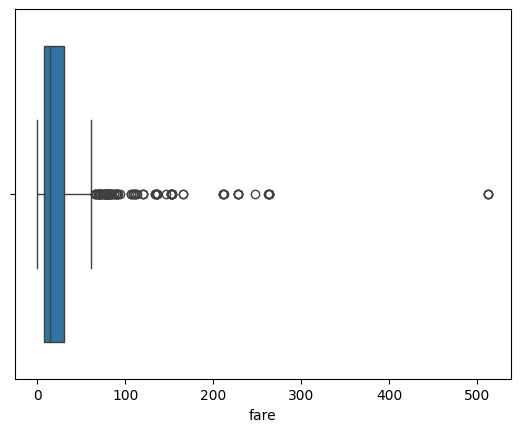

In [30]:
# jika merubah data di train maka test pun harus di rubah
# tapi jika remove row -> IQR atau z score -> hanya berlaku di train
sns.boxplot(x='fare', data=X_train)

<Axes: xlabel='fare', ylabel='Density'>

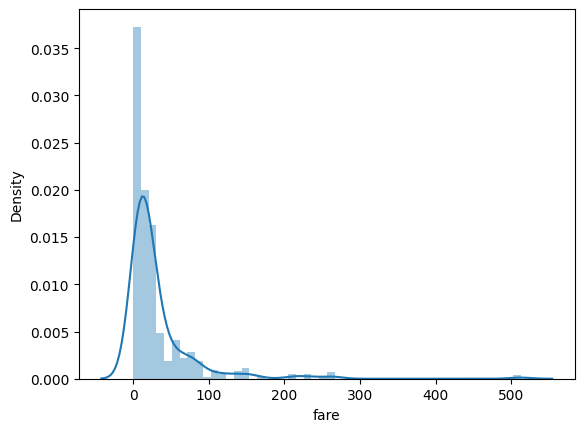

In [33]:
sns.distplot(X_train['fare'])

<Axes: xlabel='log_fare'>

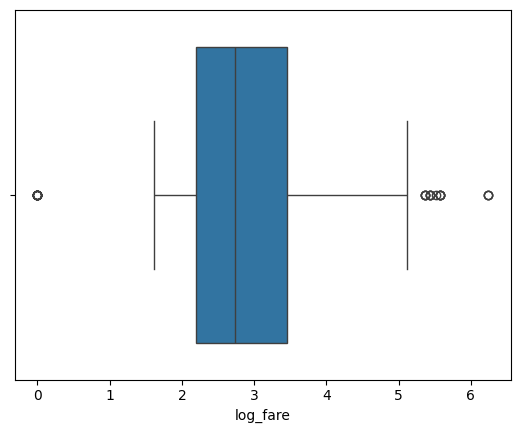

In [32]:
X_train['log_fare'] = np.log(X_train['fare'] + 1)
sns.boxplot(x='log_fare', data=X_train)

In [ ]:
# iterasi 1 : include outler
# iterasi 2 : log
# iterasi 3 : log + remove

# mana yang acc paling tinggi?

#### Imbalance handling

In [53]:
# put your code (optional)
# undersampling
# oversampling

#### Scaling

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_std = scaler.transform(X_train)

In [55]:
from sklearn.model_selection import cross_val_score

# Inisialisasi Random Forest Classifier
model = RandomForestClassifier()

# Cross-validation dengan f1_score sebagai metric
cv_scores = cross_val_score(model, X_std, y_train, cv=5, scoring='f1')

# Print hasil
print("F1-score rata-rata:", cv_scores)
print("F1-score rata-rata:", cv_scores.mean())

F1-score rata-rata: [1. 1. 1. 1. 1.]
F1-score rata-rata: 1.0


In [57]:
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, make_scorer

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Definisi scorer untuk F1 score hanya untuk label 1
scorer = make_scorer(f1_score, pos_label=1)

# Melakukan cross-validation dan menghitung skor
scores = cross_val_score(model, X_std, y_train, cv=kf, scoring=scorer)
scores, scores.mean()

(array([1., 1., 1., 1., 1.]), np.float64(1.0))

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = RandomForestClassifier()

# Inisialisasi KFold split dengan 5 kelompok
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store m etrics
f1_scores = []
recall_scores = []
precision_scores = []

for train_index, test_index in kf.split(X_std):
  # print(test_index)
  X_train_, X_val = X_std[train_index], X_std[test_index]
  y_train_, y_val = y_train.values[train_index], y_train.values[test_index]

  model.fit(X_train_, y_train_)
  y_pred = model.predict(X_val)


  f1_scores.append(f1_score(y_val, y_pred))
  recall_scores.append(precision_score(y_val, y_pred))
  precision_scores.append(f1_score(y_val, y_pred))

f1_mean, mae_std = np.mean(f1_scores), np.std(f1_scores)
recall_mean, recall_std = np.mean(recall_scores), np.std(recall_scores)
precision_mean,precision_std = np.mean(precision_scores), np.std(precision_scores)

In [61]:
f1_scores

[1.0, 1.0, 1.0, 1.0, 1.0]

### Test

#### missing value

In [21]:
# Age
X_test['age'] = X_test['age'].fillna(X_train['age'].median())



In [20]:
## Tidak boleh
# X_test['age'] = X_test['age'].fillna(X_test['age'].median())

## tidak valid ketika single test
X_test['age'].median()

29.0

In [52]:
sifulan = pd.DataFrame(
    {
       'age' : [None],
       'fare' :  [100]

    }
)
sifulan['log_fare'] = np.log(sifulan['fare']+1)
sifulan

,age,fare,log_fare
0,None,100,4.615121


In [18]:
sifulan['age'] = sifulan['age'].fillna(X_train['age'].median())

In [17]:
sifulan['age'].median()

nan

In [19]:
sifulan

,age,fare
0,28.0,100


In [43]:
# deck
X_test = X_test.drop('deck', axis=1)

In [44]:
# deck
X_test['embark_town'] = X_test['embark_town'].fillna(X_train['embark_town'].mode().iloc[0])

#### Categorical Encoding

In [26]:
# label_encoder = LabelEncoder()
# X_train['sex'] = label_encoder.fit_transform(X_train['sex'])

In [41]:
X_test['sex'] = label_encoder.transform(X_test['sex'])
X_test['embarked'] = label_encoder.transform(X_test['embarked'])
X_test['class'] = label_encoder.transform(X_test['class'])
X_test['who'] = label_encoder.transform(X_test['who'])
X_test['adult_male'] = label_encoder.transform(X_test['adult_male'])
X_test['embark_town'] = label_encoder.transform(X_test['embark_town'])
X_test['alive'] = label_encoder.transform(X_test['alive'])
X_test['alone'] = label_encoder.transform(X_test['alone'])

In [34]:
# 1 adalah female
# 0 adalah male

# 0 adalah female
# 1 adalah male

#### Outlier Handling

In [35]:
X_test['log_fare'] = np.log(X_test['fare'] + 1)

#### Scaling

In [39]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# scaler.fit(X_train)
# X_std = scaler.transform(X_train)

In [45]:
X_test_std = scaler.transform(X_test)

In [47]:
# nomalisasi -> train age min : 2 bulan dan max 75 tahun

# nomalisasi -> test -> age min : 2 bulan dan max 75 tahun
sifulan

,age,fare
0,None,100


In [49]:
sifulan['fare'].min()

100

In [50]:
sifulan['fare'].max()

100

#### Prediction

In [62]:
y_test_pred = model.predict(X_test_std)

#### Evaluation

In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       105
           1       0.41      1.00      0.58        74

    accuracy                           0.41       179
   macro avg       0.21      0.50      0.29       179
weighted avg       0.17      0.41      0.24       179



In [64]:
# 0 sehat
# 1 sakit

# org sakit -> F1 score 1

In [ ]:
# fraud : orang yang menyalahgunakan/memanfaatkan celah dari TnC promo

# Recall -> FN -> kamu negatif fraud tapi fakta nya kamu fraudster

# Precission -> FP -> kamu itu postif tapi fakta nya kama negatif

# jika user banyak yang salah di FP -> org baik terprediksi jahat -> org baik tdk bisa bertransaksi -> revenue turun -> investor marah... !!!!